In [1]:
import torch
from models.handler import Handler
from models.model import ResnetClassifier
from models.loss import FairLoss
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from torchvision import transforms
from torchvision.datasets import FashionMNIST, CIFAR10, CIFAR100, MNIST
from models.noise import InstanceDependentNoiseAdder

In [2]:
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)
device

device(type='cuda')

In [3]:
train_dataset = CIFAR10(root='data', train=True, download=False)
noise_adder = InstanceDependentNoiseAdder(train_dataset, 0.2, 10)
noise_adder.add_noise()
test_dataset = CIFAR10(root='data', train=False, download=False)
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))])

Seed: 16


# CE

In [4]:
model = ResnetClassifier()
model = model.to(device)
critertion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)
handler = Handler(model, device, critertion, optimizer, train_dataset, test_dataset, transform)

In [ ]:
handler.train(20)

Epoch 1/20: 100%|██████████| 704/704 [00:12<00:00, 56.71it/s, loss=2.09]


Epoch 1/20, Val Loss: 1.3441274037844018, Val Acc: 0.5546


Epoch 2/20: 100%|██████████| 704/704 [00:11<00:00, 59.14it/s, loss=2.05] 


Epoch 2/20, Val Loss: 1.234800078446352, Val Acc: 0.608


Epoch 3/20: 100%|██████████| 704/704 [00:12<00:00, 58.33it/s, loss=2.02] 


Epoch 3/20, Val Loss: 1.2616496817975105, Val Acc: 0.6136


Epoch 4/20: 100%|██████████| 704/704 [00:12<00:00, 58.33it/s, loss=3.24] 


Epoch 4/20, Val Loss: 1.242190905009644, Val Acc: 0.6108


Epoch 5/20:  36%|███▌      | 253/704 [00:04<00:07, 60.46it/s, loss=0.829]

Testing: 100%|██████████| 157/157 [00:01<00:00, 119.45it/s]


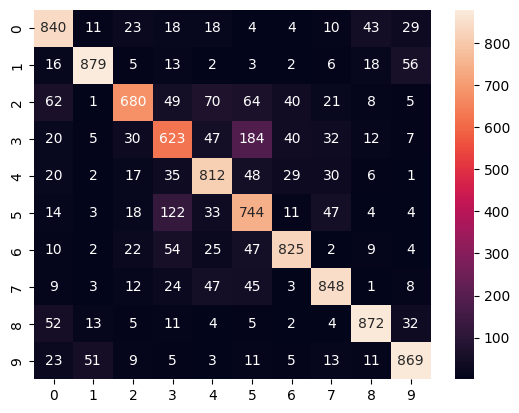


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81      1000
           1       0.91      0.88      0.89      1000
           2       0.83      0.68      0.75      1000
           3       0.65      0.62      0.64      1000
           4       0.77      0.81      0.79      1000
           5       0.64      0.74      0.69      1000
           6       0.86      0.82      0.84      1000
           7       0.84      0.85      0.84      1000
           8       0.89      0.87      0.88      1000
           9       0.86      0.87      0.86      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



In [ ]:
handler.test()

# Fair

In [ ]:
model = ResnetClassifier()
model = model.to(device)
critertion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)
handler = Handler(model, device, critertion, optimizer, train_dataset, test_dataset, transform)

Epoch 1/20: 100%|██████████| 704/704 [00:12<00:00, 54.73it/s, loss=2.59] 


Epoch 1/20, Val Loss: 0.8258105214638046, Val Acc: 0.7196


Epoch 2/20: 100%|██████████| 704/704 [00:11<00:00, 58.97it/s, loss=1.35] 


Epoch 2/20, Val Loss: 0.9264101039005231, Val Acc: 0.707


Epoch 3/20: 100%|██████████| 704/704 [00:12<00:00, 57.56it/s, loss=0.16] 


...

Epoch 18/20, Val Loss: 0.9011245177516455, Val Acc: 0.808


Epoch 19/20: 100%|██████████| 704/704 [00:11<00:00, 60.25it/s, loss=3.17]   


Epoch 19/20, Val Loss: 1.0048545961138569, Val Acc: 0.7848


Epoch 20/20: 100%|██████████| 704/704 [00:11<00:00, 59.15it/s, loss=1.36]   


Epoch 20/20, Val Loss: 0.8166186228583131, Val Acc: 0.8118


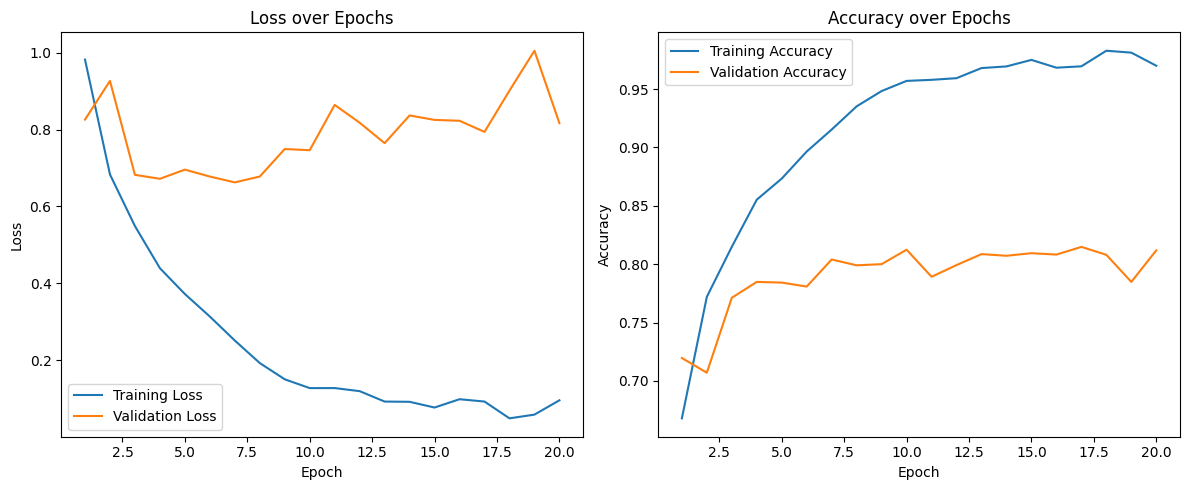

In [ ]:
handler.train(20)

Testing: 100%|██████████| 157/157 [00:01<00:00, 109.85it/s]


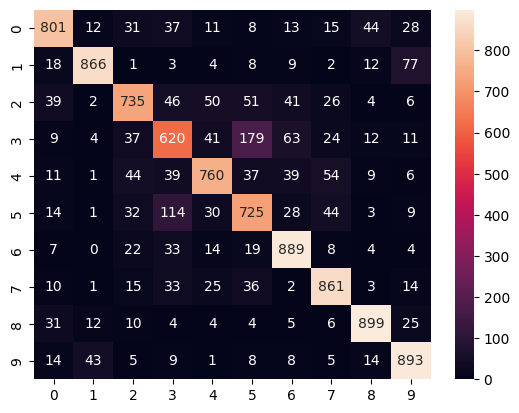


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1000
           1       0.92      0.87      0.89      1000
           2       0.79      0.73      0.76      1000
           3       0.66      0.62      0.64      1000
           4       0.81      0.76      0.78      1000
           5       0.67      0.72      0.70      1000
           6       0.81      0.89      0.85      1000
           7       0.82      0.86      0.84      1000
           8       0.90      0.90      0.90      1000
           9       0.83      0.89      0.86      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000



In [ ]:
handler.test()